# Bayes' Theorem

Bayes' Theorem is one of the most ubiquitous results in probability for computer scientists. It provides a way to **reverse a conditional probability** — turning $P(E|F)$ into $P(F|E)$.

- **Derivation** — From the definition of conditional probability
- **Terminology** — Prior, Likelihood, Posterior, Normalization constant
- **Medical Test Example** — The classic application
- **Natural Frequency Intuition** — Thinking in counts, not fractions
- **General Law of Total Probability** — Handling multiple hypotheses
- **Unknown Normalization Constant** — The odds-ratio trick

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Bayes' Theorem](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/bayes_theorem/)

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba

from libs.venn import venn, Color

np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## 1. Deriving Bayes' Theorem

Start with the definition of conditional probability:

$$P(F|E) = \frac{P(F \text{ and } E)}{P(E)}$$

Apply the **chain rule** to rewrite $P(F \text{ and } E) = P(E|F) \cdot P(F)$:

$$P(F|E) = \frac{P(E|F) \cdot P(F)}{P(E)}$$

That's it! This is **Bayes' Theorem**.

> **Bayes' Theorem:**
>
> $$\boxed{P(B|E) = \frac{P(E|B) \cdot P(B)}{P(E)}}$$
>
> Where $B$ = **belief** (unobservable), $E$ = **evidence** (observed).

### Expanding $P(E)$ — Law of Total Probability

The denominator $P(E)$ is often not directly known. We can expand it using the **Law of Total Probability**. Since $B$ and $B^c$ partition the sample space:

$$P(E) = P(E|B) \cdot P(B) + P(E|B^c) \cdot P(B^c)$$

Substituting into Bayes' Theorem gives the **expanded form**:

> **Bayes' Theorem (expanded):**
>
> $$\boxed{P(B|E) = \frac{P(E|B) \cdot P(B)}{P(E|B) \cdot P(B) + P(E|B^c) \cdot P(B^c)}}$$

This form is useful because we typically **do** know the likelihood under each hypothesis ($P(E|B)$ and $P(E|B^c)$) and the prior ($P(B)$), even when $P(E)$ is not given directly.

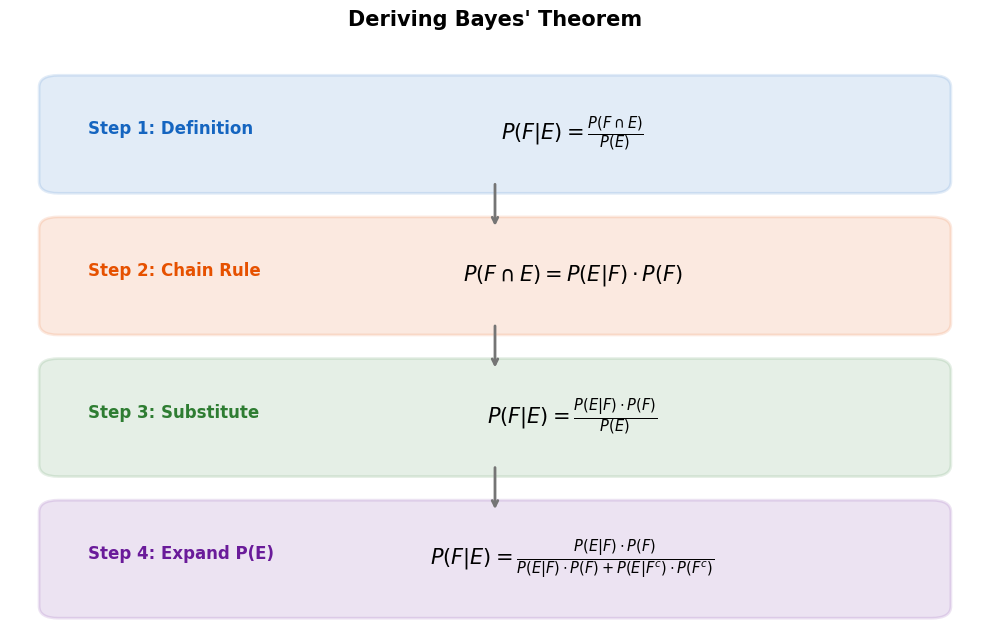

In [2]:
# --- Visual: the derivation step by step ---

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.axis("off")

steps = [
    ("Step 1: Definition", r"$P(F|E) = \frac{P(F \cap E)}{P(E)}$"),
    ("Step 2: Chain Rule", r"$P(F \cap E) = P(E|F) \cdot P(F)$"),
    ("Step 3: Substitute", r"$P(F|E) = \frac{P(E|F) \cdot P(F)}{P(E)}$"),
    ("Step 4: Expand P(E)", r"$P(F|E) = \frac{P(E|F) \cdot P(F)}{P(E|F) \cdot P(F) + P(E|F^c) \cdot P(F^c)}$"),
]

colors = ["#1565C0", "#E65100", "#2E7D32", "#6A1B9A"]

for i, (label, formula) in enumerate(steps):
    y = 0.82 - i * 0.24
    # Box
    rect = patches.FancyBboxPatch((0.05, y - 0.06), 0.9, 0.16,
        boxstyle="round,pad=0.02", facecolor=colors[i], alpha=0.12,
        edgecolor=colors[i], linewidth=2)
    ax.add_patch(rect)
    ax.text(0.08, y + 0.02, label, fontsize=12, fontweight="bold",
            color=colors[i], transform=ax.transAxes)
    ax.text(0.58, y + 0.02, formula, fontsize=15,
            ha="center", va="center", transform=ax.transAxes)

# Arrows
for i in range(3):
    y_start = 0.82 - i * 0.24 - 0.06
    y_end = 0.82 - (i + 1) * 0.24 + 0.10
    ax.annotate("", xy=(0.5, y_end), xytext=(0.5, y_start),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="#757575", lw=2))

ax.set_title("Deriving Bayes' Theorem", fontsize=15, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

---

## 2. The Terms of Bayes' Theorem

Each piece in the formula has a name:

| Term | Name | Meaning |
|---|---|---|
| $P(B)$ | **Prior** | Belief **before** seeing evidence |
| $P(E \mid B)$ | **Likelihood** | How likely is the evidence if $B$ is true |
| $P(B \mid E)$ | **Posterior** | Updated belief **after** seeing evidence |
| $P(E)$ | **Normalization constant** | Total probability of the evidence |

In words:

$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

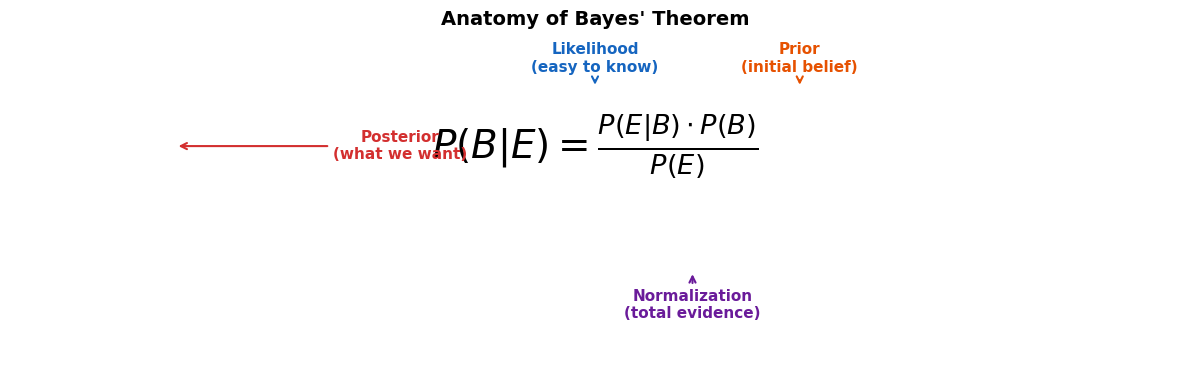

In [3]:
# --- Visual: anatomy of Bayes' Theorem ---

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)

# Central formula
ax.text(6, 2.8, r"$P(B|E) = \frac{P(E|B) \cdot P(B)}{P(E)}$",
        fontsize=28, ha="center", va="center")

# Annotations
annotations = [
    (1.7, 2.8, 4.0, 2.8, "Posterior\n(what we want)", "#D32F2F"),
    (6.0, 3.5, 6.0, 3.85, "Likelihood\n(easy to know)", "#1565C0"),
    (8.1, 3.5, 8.1, 3.85, "Prior\n(initial belief)", "#E65100"),
    (7.0, 1.3, 7.0, 0.9, "Normalization\n(total evidence)", "#6A1B9A"),
]

for x1, y1, x2, y2, label, color in annotations:
    ax.annotate(label, xy=(x1, y1), xytext=(x2, y2),
                fontsize=11, fontweight="bold", color=color,
                ha="center", va="center",
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

ax.set_title("Anatomy of Bayes' Theorem", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### Why Is Bayes' Theorem Useful?

In many real-world problems, we observe **evidence** and want to infer an **unobservable belief**:

| Belief $B$ (hard to observe) | Evidence $E$ (easy to observe) | Causality |
|---|---|---|
| Patient has disease | Test result is positive | Disease causes test result |
| Student understands concept | Student's exam answer | Knowledge causes answers |
| Phone at location $X$ | Signal strength from tower | Location causes signal |
| Email is spam | Email contains certain words | Spam causes word patterns |

It is usually much easier to estimate $P(E|B)$ (likelihood) than $P(B|E)$ (posterior). Bayes' Theorem bridges the gap.

---

## 3. Medical Test Example

This is the classic application of Bayes' Theorem.

You take a medical test and it comes back **positive**. What is the probability you actually have the disease?

**Given information:**
- $P(I)$ = probability of illness in the population = **0.13** (13%)
- $P(+|I)$ = probability of positive test given illness (**sensitivity**) = **0.92**
- $P(+|I^C)$ = probability of positive test given no illness (**false positive rate**) = **0.10**

**Question:** $P(I|+) = ?$

In [4]:
# --- Bayes' Theorem: Medical Test ---

P_I = 0.13           # Prior: natural rate of illness
P_pos_I = 0.92       # Sensitivity: P(+|Illness)
P_pos_notI = 0.10    # False positive rate: P(+|No Illness)

P_notI = 1 - P_I

# Bayes' Theorem with Law of Total Probability
# P(I|+) = P(+|I) * P(I) / [P(+|I)*P(I) + P(+|I^C)*P(I^C)]

numerator = P_pos_I * P_I
denominator = P_pos_I * P_I + P_pos_notI * P_notI
P_I_given_pos = numerator / denominator

print("Medical Test: Bayes' Theorem")
print("=" * 50)
print(f"Prior:       P(I)      = {P_I}")
print(f"Sensitivity: P(+|I)    = {P_pos_I}")
print(f"False pos:   P(+|I^C)  = {P_pos_notI}")
print()
print("Applying Bayes' Theorem with Total Probability:")
print(f"  P(I|+) = P(+|I) * P(I) / [P(+|I)*P(I) + P(+|I^C)*P(I^C)]")
print(f"         = ({P_pos_I})({P_I}) / [({P_pos_I})({P_I}) + ({P_pos_notI})({P_notI})]")
print(f"         = {numerator:.4f} / [{numerator:.4f} + {P_pos_notI * P_notI:.4f}]")
print(f"         = {numerator:.4f} / {denominator:.4f}")
print(f"         = {P_I_given_pos:.4f}")
print()
print(f"Result: A positive test means ~{P_I_given_pos:.0%} chance of illness.")
print(f"        The test is good, but far from certain!")

Medical Test: Bayes' Theorem
Prior:       P(I)      = 0.13
Sensitivity: P(+|I)    = 0.92
False pos:   P(+|I^C)  = 0.1

Applying Bayes' Theorem with Total Probability:
  P(I|+) = P(+|I) * P(I) / [P(+|I)*P(I) + P(+|I^C)*P(I^C)]
         = (0.92)(0.13) / [(0.92)(0.13) + (0.1)(0.87)]
         = 0.1196 / [0.1196 + 0.0870]
         = 0.1196 / 0.2066
         = 0.5789

Result: A positive test means ~58% chance of illness.
        The test is good, but far from certain!


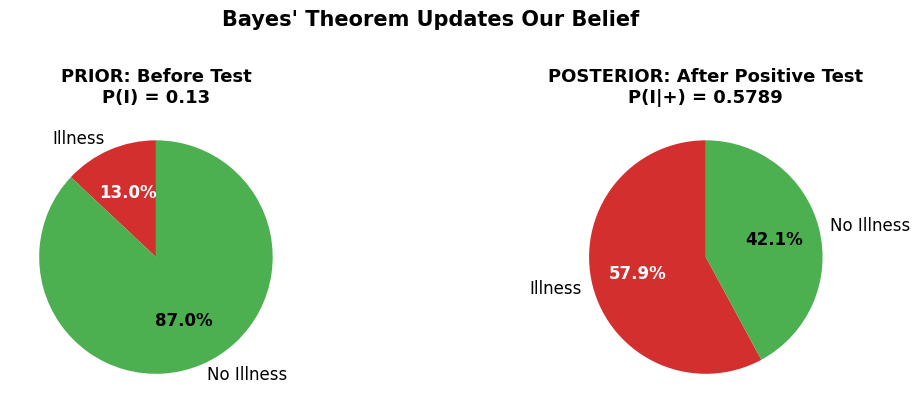

In [5]:
# --- Visual: Prior vs Posterior ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Prior belief (before test)
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [P_I, P_notI],
    labels=["Illness", "No Illness"],
    colors=["#D32F2F", "#4CAF50"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)
autotexts[0].set_color("white")
autotexts[0].set_fontweight("bold")
autotexts[1].set_fontweight("bold")
ax.set_title("PRIOR: Before Test\nP(I) = 0.13", fontsize=13, fontweight="semibold")

# Right: Posterior belief (after positive test)
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    [P_I_given_pos, 1 - P_I_given_pos],
    labels=["Illness", "No Illness"],
    colors=["#D32F2F", "#4CAF50"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)
autotexts[0].set_color("white")
autotexts[0].set_fontweight("bold")
autotexts[1].set_fontweight("bold")
ax.set_title(f"POSTERIOR: After Positive Test\nP(I|+) = {P_I_given_pos:.4f}",
             fontsize=13, fontweight="semibold")

fig.suptitle("Bayes' Theorem Updates Our Belief", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### The Surprise

Even with a **92% sensitive** test and only a **10% false positive rate**, a positive result gives only about a **58% chance** of illness. 

Why? Because the disease is **rare** (13%). The large number of healthy people means false positives still outnumber many true positives. The prior matters enormously!

---

## 4. Natural Frequency Intuition

Bayes' Theorem can feel abstract. A powerful way to build intuition is to think in **counts** rather than probabilities.

Imagine a population of **1000 people**:

In [6]:
# --- Natural frequency breakdown ---

N_POP = 1000

n_ill = int(N_POP * P_I)           # People with illness
n_healthy = N_POP - n_ill          # People without illness

n_ill_pos = round(n_ill * P_pos_I)       # Ill AND test positive (true positives)
n_ill_neg = n_ill - n_ill_pos             # Ill AND test negative (false negatives)

n_healthy_pos = round(n_healthy * P_pos_notI)  # Healthy AND test positive (false positives)
n_healthy_neg = n_healthy - n_healthy_pos       # Healthy AND test negative (true negatives)

n_total_pos = n_ill_pos + n_healthy_pos

print(f"Population: {N_POP} people")
print(f"{'':>4} Illness:  {n_ill}  |  No Illness: {n_healthy}")
print()
print(f"Test results:")
print(f"  Ill + Test Positive  (True Positives):   {n_ill_pos}")
print(f"  Ill + Test Negative  (False Negatives):  {n_ill_neg}")
print(f"  Healthy + Test Positive (False Positives): {n_healthy_pos}")
print(f"  Healthy + Test Negative (True Negatives):  {n_healthy_neg}")
print()
print(f"Total who test positive: {n_total_pos}")
print(f"Of those, truly ill: {n_ill_pos}")
print(f"P(Ill | +) approx {n_ill_pos}/{n_total_pos} = {n_ill_pos/n_total_pos:.4f}")
print(f"Exact Bayes answer: {P_I_given_pos:.4f}")

Population: 1000 people
     Illness:  130  |  No Illness: 870

Test results:
  Ill + Test Positive  (True Positives):   120
  Ill + Test Negative  (False Negatives):  10
  Healthy + Test Positive (False Positives): 87
  Healthy + Test Negative (True Negatives):  783

Total who test positive: 207
Of those, truly ill: 120
P(Ill | +) approx 120/207 = 0.5797
Exact Bayes answer: 0.5789


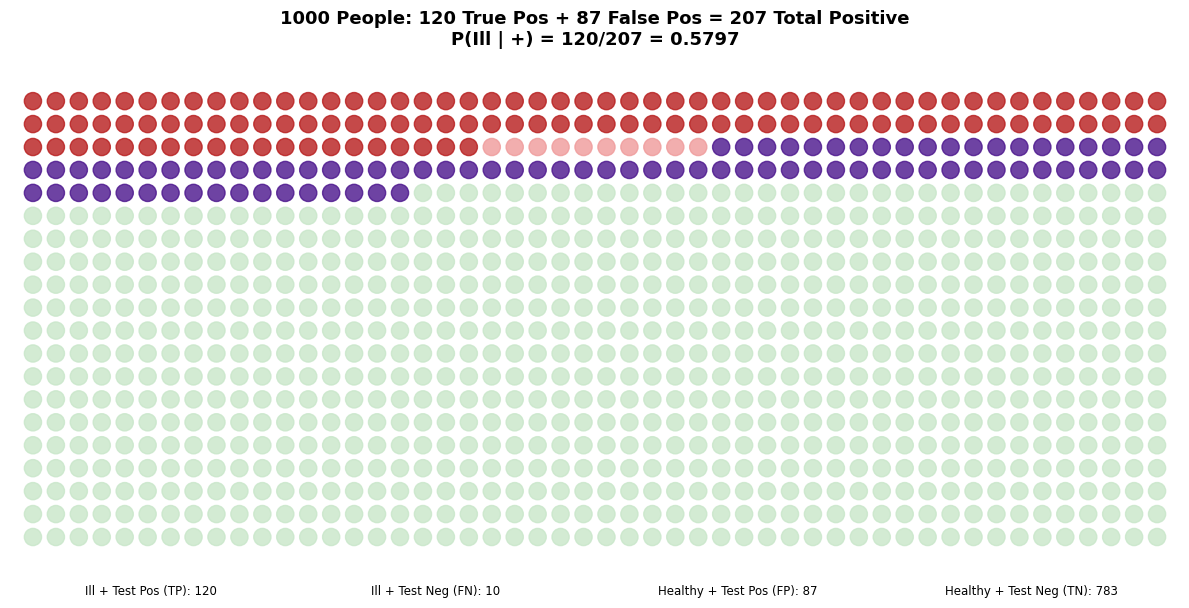

In [7]:
# --- Visual: population grid (1000 dots) ---

fig, ax = plt.subplots(figsize=(12, 7))

cols = 50
rows = N_POP // cols

# Assign each person a category
# Order: True Positives, False Negatives, False Positives, True Negatives
categories = (
    [0] * n_ill_pos +     # True Positive (ill, test +)
    [1] * n_ill_neg +     # False Negative (ill, test -)
    [2] * n_healthy_pos + # False Positive (healthy, test +)
    [3] * n_healthy_neg   # True Negative (healthy, test -)
)

cat_colors = ["#B71C1C", "#EF9A9A", "#4A148C", "#C8E6C9"]
cat_labels = ["Ill + Test Pos (TP)", "Ill + Test Neg (FN)",
              "Healthy + Test Pos (FP)", "Healthy + Test Neg (TN)"]

for idx in range(N_POP):
    row = idx // cols
    col = idx % cols
    cat = categories[idx]
    circle = plt.Circle((col * 0.4 + 0.2, (rows - 1 - row) * 0.4 + 0.2),
                         0.15, color=cat_colors[cat], alpha=0.8)
    ax.add_patch(circle)

ax.set_xlim(-0.2, cols * 0.4 + 0.2)
ax.set_ylim(-0.5, rows * 0.4 + 0.5)
ax.set_aspect("equal")
ax.axis("off")

# Legend
for i, (color, label) in enumerate(zip(cat_colors, cat_labels)):
    count = [n_ill_pos, n_ill_neg, n_healthy_pos, n_healthy_neg][i]
    ax.add_patch(patches.Rectangle((0.5 + i * 5.0, -1.0), 0.5, 0.5,
                                    facecolor=color, alpha=0.8))
    ax.text(1.1 + i * 5.0, -0.75, f"{label}: {count}", fontsize=8.5, va="center")

ax.set_title(f"1000 People: {n_ill_pos} True Pos + {n_healthy_pos} False Pos = {n_total_pos} Total Positive\n"
             f"P(Ill | +) = {n_ill_pos}/{n_total_pos} = {n_ill_pos/n_total_pos:.4f}",
             fontsize=13, fontweight="semibold", pad=12)
plt.tight_layout()
plt.show()

### Reading the Grid

- **Dark red** = truly ill, test positive (True Positives)
- **Light red** = truly ill, test negative (False Negatives — the test missed them)
- **Purple** = healthy, but test says positive (False Positives!)
- **Light green** = healthy, test negative (True Negatives)

The question "P(Ill | +)" asks: **of the dark-red + purple dots** (all who tested positive), **what fraction is dark red** (truly ill)?

---

## 5. How the Prior Changes Everything

The most counterintuitive aspect of Bayes' Theorem is the **huge effect of the prior** $P(B)$.

Let's see what happens to $P(\text{Ill}|+)$ as we vary the prevalence of the disease, keeping the test accuracy fixed.

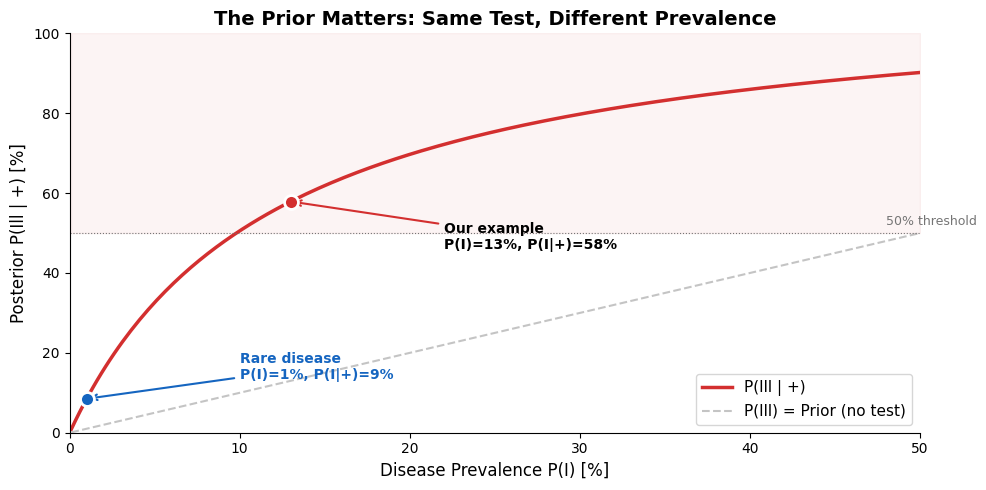

When disease prevalence is only 1%:  P(Ill|+) = 8.50%
When disease prevalence is 13%:      P(Ill|+) = 57.89%
When disease prevalence is 50%:      P(Ill|+) = 90.20%


In [8]:
# --- Effect of prior on posterior ---

prevalences = np.linspace(0.001, 0.5, 200)

def bayes_medical(P_I, P_pos_I=0.92, P_pos_notI=0.10):
    num = P_pos_I * P_I
    den = P_pos_I * P_I + P_pos_notI * (1 - P_I)
    return num / den

posteriors = [bayes_medical(p) for p in prevalences]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(prevalences * 100, np.array(posteriors) * 100,
        color="#D32F2F", linewidth=2.5, label="P(Ill | +)")
ax.plot(prevalences * 100, prevalences * 100,
        color="#9E9E9E", linewidth=1.5, linestyle="--", alpha=0.6,
        label="P(Ill) = Prior (no test)")

# Mark the specific example
ax.scatter([13], [bayes_medical(0.13) * 100], color="#D32F2F",
           s=100, zorder=5, edgecolors="white", linewidth=2)
ax.annotate(f"Our example\nP(I)=13%, P(I|+)={bayes_medical(0.13):.0%}",
            xy=(13, bayes_medical(0.13) * 100),
            xytext=(22, bayes_medical(0.13) * 100 - 12),
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#D32F2F", lw=1.5))

# Mark rare disease case
rare_post = bayes_medical(0.01)
ax.scatter([1], [rare_post * 100], color="#1565C0",
           s=100, zorder=5, edgecolors="white", linewidth=2)
ax.annotate(f"Rare disease\nP(I)=1%, P(I|+)={rare_post:.0%}",
            xy=(1, rare_post * 100),
            xytext=(10, rare_post * 100 + 5),
            fontsize=10, fontweight="bold", color="#1565C0",
            arrowprops=dict(arrowstyle="->", color="#1565C0", lw=1.5))

ax.fill_between(prevalences * 100, 50, 100, alpha=0.05, color="#D32F2F")
ax.axhline(50, color="#757575", linewidth=0.8, linestyle=":")
ax.text(48, 52, "50% threshold", fontsize=9, color="#757575")

ax.set_xlabel("Disease Prevalence P(I) [%]", fontsize=12)
ax.set_ylabel("Posterior P(Ill | +) [%]", fontsize=12)
ax.set_title("The Prior Matters: Same Test, Different Prevalence",
             fontsize=14, fontweight="semibold")
ax.legend(fontsize=11, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 50)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"When disease prevalence is only 1%:  P(Ill|+) = {bayes_medical(0.01):.2%}")
print(f"When disease prevalence is 13%:      P(Ill|+) = {bayes_medical(0.13):.2%}")
print(f"When disease prevalence is 50%:      P(Ill|+) = {bayes_medical(0.50):.2%}")

When the disease is **rare** (1%), even a good test gives only ~8% chance of actually being ill after a positive test! Most positives are **false positives** because healthy people vastly outnumber sick ones.

---

## 6. Venn Diagram View

Bayes' Theorem involves the overlap between the Belief event and the Evidence event.

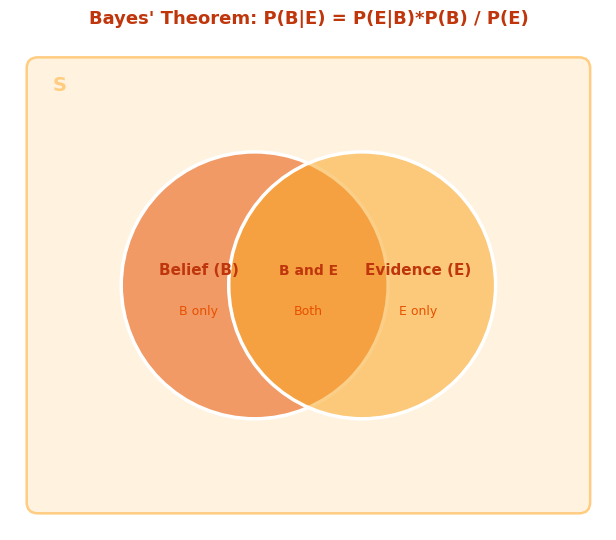

In [9]:
venn("""
venn-beta
    title "Bayes' Theorem: P(B|E) = P(E|B)*P(B) / P(E)"
    set B["Belief (B)"]
        text b1["B only"]
    set E["Evidence (E)"]
        text e1["E only"]
    union B, E["B and E"]
        text be1["Both"]
""", color_scheme=Color.SUNSET)

- $P(B|E)$ = fraction of the **Evidence circle** that overlaps with Belief
- $P(E|B)$ = fraction of the **Belief circle** that overlaps with Evidence
- Bayes' Theorem converts one into the other!

---

## 7. Bayes with the General Law of Total Probability

When there are **more than two** hypotheses $B_1, B_2, \ldots, B_n$ (mutually exclusive and exhaustive), we use:

$$P(B_i|E) = \frac{P(E|B_i) \cdot P(B_i)}{\sum_{j=1}^{n} P(E|B_j) \cdot P(B_j)}$$

The denominator is the **law of total probability**: the total probability of the evidence across all hypotheses.

In [10]:
# --- Example: Phone tracking with 4 possible locations ---
#
# A phone could be at one of 4 locations.
# We measure a signal strength from a cell tower.
# Given the true location, we know the probability of this signal.

locations = ["Home", "Office", "Cafe", "Park"]

# Prior beliefs: where do we think the phone is?
priors = np.array([0.40, 0.30, 0.20, 0.10])

# Likelihood: P(observed signal | phone at location_i)
# (e.g., based on distance to cell tower)
likelihoods = np.array([0.1, 0.3, 0.5, 0.05])

# Law of Total Probability: P(E)
P_E = np.sum(likelihoods * priors)

# Posterior: P(location_i | signal)
posteriors = (likelihoods * priors) / P_E

print(f"{'Location':<10} {'Prior P(B)':>12} {'Likelihood P(E|B)':>18} {'Posterior P(B|E)':>18}")
print("-" * 60)
for loc, pr, lk, po in zip(locations, priors, likelihoods, posteriors):
    print(f"{loc:<10} {pr:>12.2f} {lk:>18.2f} {po:>18.4f}")
print("-" * 60)
print(f"{'Total':>10} {priors.sum():>12.2f} {'P(E) =':>18} {P_E:>18.4f}")
print(f"\nMost likely location after evidence: {locations[np.argmax(posteriors)]}")
print(f"  (Prior said: {locations[np.argmax(priors)]})")

Location     Prior P(B)  Likelihood P(E|B)   Posterior P(B|E)
------------------------------------------------------------
Home               0.40               0.10             0.1702
Office             0.30               0.30             0.3830
Cafe               0.20               0.50             0.4255
Park               0.10               0.05             0.0213
------------------------------------------------------------
     Total         1.00             P(E) =             0.2350

Most likely location after evidence: Cafe
  (Prior said: Home)


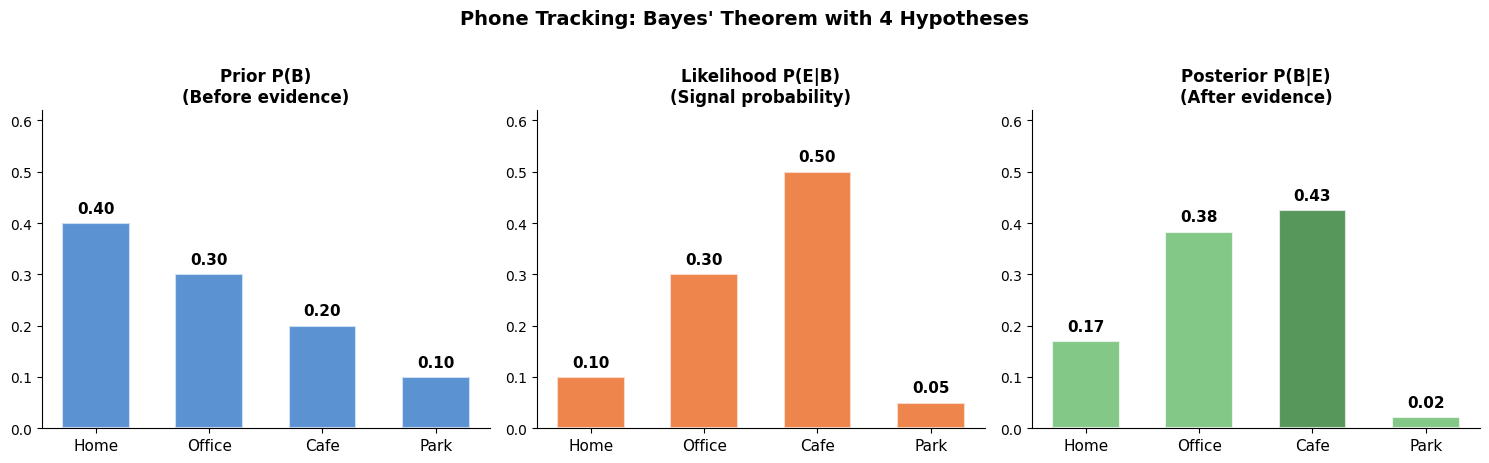

In [11]:
# --- Visual: Prior vs Posterior bar chart ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

bar_kw = dict(edgecolor="white", linewidth=1.5)
x = np.arange(len(locations))
w = 0.6

# Prior
axes[0].bar(x, priors, w, color="#1565C0", alpha=0.7, **bar_kw)
axes[0].set_title("Prior P(B)\n(Before evidence)", fontsize=12, fontweight="semibold")
for i, v in enumerate(priors):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")

# Likelihood
axes[1].bar(x, likelihoods, w, color="#E65100", alpha=0.7, **bar_kw)
axes[1].set_title("Likelihood P(E|B)\n(Signal probability)", fontsize=12, fontweight="semibold")
for i, v in enumerate(likelihoods):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")

# Posterior
colors_post = ["#2E7D32" if i == np.argmax(posteriors) else "#66BB6A" for i in range(len(posteriors))]
axes[2].bar(x, posteriors, w, color=colors_post, alpha=0.8, **bar_kw)
axes[2].set_title("Posterior P(B|E)\n(After evidence)", fontsize=12, fontweight="semibold")
for i, v in enumerate(posteriors):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(locations, fontsize=11)
    ax.set_ylim(0, max(posteriors.max(), priors.max(), likelihoods.max()) + 0.12)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Phone Tracking: Bayes' Theorem with 4 Hypotheses",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Notice how the posterior combines **both** prior and likelihood:

- The **Cafe** has the highest likelihood (signal fits best) **and** a moderate prior, so it wins the posterior.
- **Home** had the highest prior, but its low likelihood pulled it down.
- **Park** had both low prior and low likelihood, so it remains unlikely.

---

## 8. Unknown Normalization Constant: The Odds Ratio

Sometimes computing $P(E)$ is hard. A clever trick: compute the **ratio** of posterior probabilities, and $P(E)$ cancels out!

$$\frac{P(B|E)}{P(B^C|E)} = \frac{P(E|B) \cdot P(B) / P(E)}{P(E|B^C) \cdot P(B^C) / P(E)} = \frac{P(E|B) \cdot P(B)}{P(E|B^C) \cdot P(B^C)}$$

This gives us the **posterior odds**: how many times more likely $B$ is than $B^C$, given the evidence.

In [12]:
# --- Odds ratio: Medical test example ---

prior_odds = P_I / P_notI
likelihood_ratio = P_pos_I / P_pos_notI
posterior_odds = likelihood_ratio * prior_odds

# Convert odds back to probability: P = odds / (1 + odds)
P_from_odds = posterior_odds / (1 + posterior_odds)

print("Odds Ratio Approach")
print("=" * 45)
print(f"Prior odds     = P(I)/P(I^C)     = {P_I}/{P_notI:.2f} = {prior_odds:.4f}")
print(f"Likelihood ratio = P(+|I)/P(+|I^C) = {P_pos_I}/{P_pos_notI} = {likelihood_ratio:.2f}")
print(f"Posterior odds = {likelihood_ratio:.2f} x {prior_odds:.4f} = {posterior_odds:.4f}")
print()
print(f"Meaning: illness is {posterior_odds:.2f}x more likely than no illness")
print(f"         given a positive test.")
print()
print(f"Convert to probability: {posterior_odds:.4f} / (1 + {posterior_odds:.4f}) = {P_from_odds:.4f}")
print(f"Matches Bayes directly: {P_I_given_pos:.4f}")

Odds Ratio Approach
Prior odds     = P(I)/P(I^C)     = 0.13/0.87 = 0.1494
Likelihood ratio = P(+|I)/P(+|I^C) = 0.92/0.1 = 9.20
Posterior odds = 9.20 x 0.1494 = 1.3747

Meaning: illness is 1.37x more likely than no illness
         given a positive test.

Convert to probability: 1.3747 / (1 + 1.3747) = 0.5789
Matches Bayes directly: 0.5789


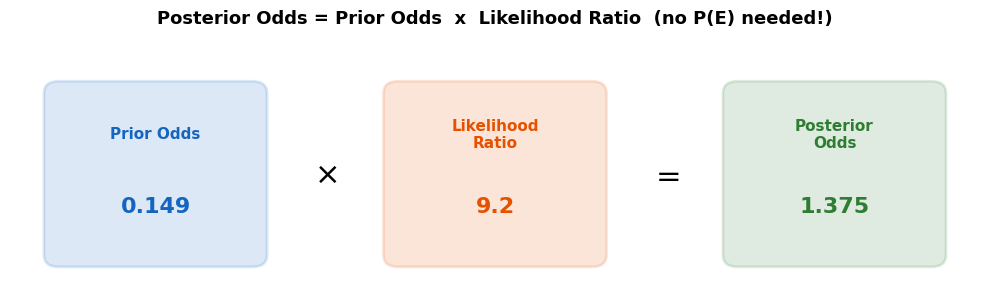

In [13]:
# --- Visual: odds decomposition ---

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

components = [
    ("Prior Odds", f"{prior_odds:.3f}", "#1565C0"),
    ("Likelihood\nRatio", f"{likelihood_ratio:.1f}", "#E65100"),
    ("Posterior\nOdds", f"{posterior_odds:.3f}", "#2E7D32"),
]

positions = [1.5, 5.0, 8.5]

for (label, value, color), xpos in zip(components, positions):
    rect = patches.FancyBboxPatch((xpos - 1.0, 0.3), 2.0, 2.0,
        boxstyle="round,pad=0.15", facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(xpos, 1.8, label, ha="center", va="center",
            fontsize=11, fontweight="bold", color=color)
    ax.text(xpos, 0.9, value, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color)

# Multiplication signs
ax.text(3.25, 1.3, r"$\times$", fontsize=22, ha="center", va="center")
ax.text(6.75, 1.3, r"$=$", fontsize=22, ha="center", va="center")

ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.set_title("Posterior Odds = Prior Odds  x  Likelihood Ratio  (no P(E) needed!)",
             fontsize=13, fontweight="semibold", pad=10)
plt.tight_layout()
plt.show()

---

## 9. Sequential Bayesian Updates

A powerful feature of Bayes' Theorem: when you get **multiple pieces of evidence**, you can apply it **repeatedly**. The posterior from one update becomes the prior for the next.

$$P(B|E_1, E_2) \propto P(E_2|B) \cdot P(B|E_1)$$

In [14]:
# --- Sequential updates: repeated medical tests ---
#
# Take the same test 3 times (assume tests are independent given disease status).
# Results: Positive, Positive, Negative
#
# How does our belief update with each test?

test_results = ["+", "+", "-"]  # Sequence of test outcomes

belief = P_I  # Start with prior
history = [belief]

print(f"{'Step':<12} {'Test Result':>12} {'P(Ill)':>12}")
print("-" * 38)
print(f"{'Prior':<12} {'---':>12} {belief:>12.4f}")

for i, result in enumerate(test_results):
    if result == "+":
        likelihood = P_pos_I
        likelihood_neg = P_pos_notI
    else:
        likelihood = 1 - P_pos_I       # P(-|I)
        likelihood_neg = 1 - P_pos_notI # P(-|I^C)
    
    # Bayes update
    numerator = likelihood * belief
    denominator = likelihood * belief + likelihood_neg * (1 - belief)
    belief = numerator / denominator
    history.append(belief)
    print(f"{'Update ' + str(i+1):<12} {result:>12} {belief:>12.4f}")

print()
print(f"After 2 positives and 1 negative: P(Ill) = {belief:.4f}")

Step          Test Result       P(Ill)
--------------------------------------
Prior                 ---       0.1300
Update 1                +       0.5789
Update 2                +       0.9267
Update 3                -       0.5292

After 2 positives and 1 negative: P(Ill) = 0.5292


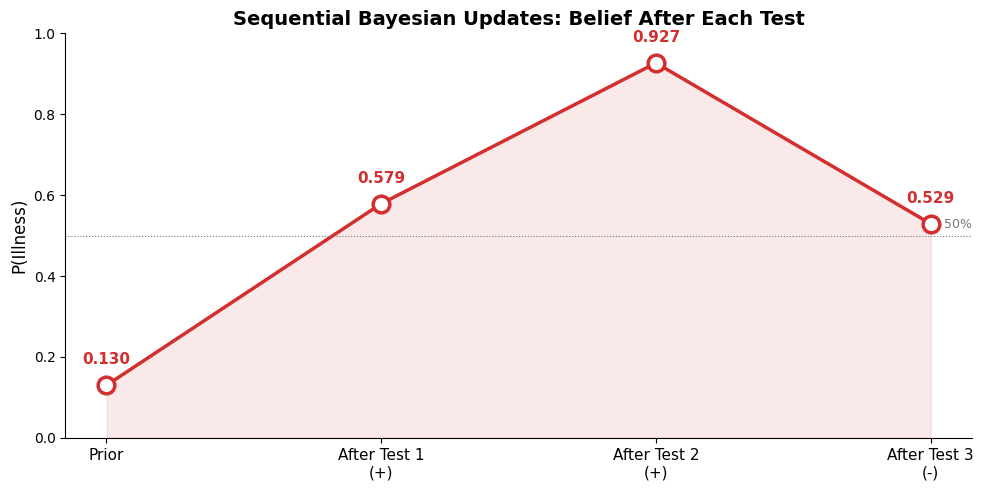

In [15]:
# --- Visual: belief trajectory ---

fig, ax = plt.subplots(figsize=(10, 5))

x_labels = ["Prior"] + [f"After Test {i+1}\n({r})" for i, r in enumerate(test_results)]
x = range(len(history))

ax.plot(x, history, "o-", color="#D32F2F", linewidth=2.5, markersize=12,
        markerfacecolor="white", markeredgewidth=2.5, markeredgecolor="#D32F2F")

for i, (xi, yi) in enumerate(zip(x, history)):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points",
                xytext=(0, 15), ha="center", fontsize=11, fontweight="bold",
                color="#D32F2F")

# Shade region
ax.axhline(0.5, color="#757575", linewidth=0.8, linestyle=":")
ax.text(3.05, 0.52, "50%", fontsize=9, color="#757575")

ax.fill_between(x, history, alpha=0.1, color="#D32F2F")

ax.set_xticks(list(x))
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_ylabel("P(Illness)", fontsize=12)
ax.set_title("Sequential Bayesian Updates: Belief After Each Test",
             fontsize=14, fontweight="semibold")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Each positive test **increases** belief; the negative test **decreases** it. The posterior after one test becomes the prior for the next — Bayes' Theorem applied iteratively.

---

## 10. Monte Carlo Verification

Let's verify our medical test result with simulation.

In [16]:
# --- Monte Carlo: simulate medical tests ---

N_SIM = 500_000

# Step 1: Generate illness status
is_ill = np.random.random(N_SIM) < P_I

# Step 2: Generate test results based on illness status
test_positive = np.where(
    is_ill,
    np.random.random(N_SIM) < P_pos_I,      # Sensitivity
    np.random.random(N_SIM) < P_pos_notI     # False positive rate
)

# Step 3: Among those who tested positive, what fraction is ill?
n_positive = test_positive.sum()
n_ill_and_positive = (is_ill & test_positive).sum()

P_sim = n_ill_and_positive / n_positive

print(f"Simulation ({N_SIM:,} people):")
print(f"  Total who tested positive: {n_positive:,}")
print(f"  Of those, truly ill:       {n_ill_and_positive:,}")
print(f"  P(Ill | +) simulated:      {P_sim:.4f}")
print(f"  P(Ill | +) exact (Bayes):  {P_I_given_pos:.4f}")
print(f"  |Difference|:              {abs(P_sim - P_I_given_pos):.4f}")

Simulation (500,000 people):
  Total who tested positive: 103,153
  Of those, truly ill:       59,638
  P(Ill | +) simulated:      0.5782
  P(Ill | +) exact (Bayes):  0.5789
  |Difference|:              0.0007


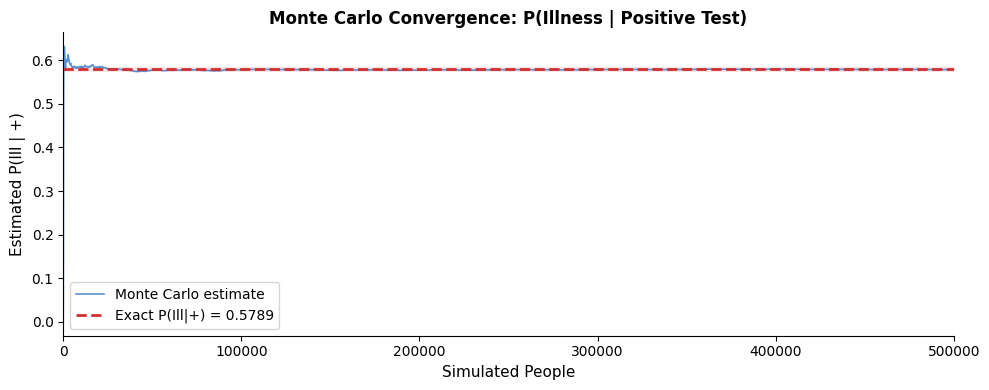

In [17]:
# --- Convergence plot ---

# Running estimate of P(Ill | +)
cum_pos = np.cumsum(test_positive)
cum_ill_pos = np.cumsum(is_ill & test_positive)

with np.errstate(divide="ignore", invalid="ignore"):
    running_est = np.where(cum_pos > 0, cum_ill_pos / cum_pos, 0.0)

step = max(1, N_SIM // 2000)
xs = np.arange(1, N_SIM + 1)[::step]
ys = running_est[::step]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, ys, color="#1565C0", alpha=0.7, linewidth=1.2,
        label="Monte Carlo estimate")
ax.axhline(P_I_given_pos, color="#D32F2F", linestyle="--", linewidth=2,
           label=f"Exact P(Ill|+) = {P_I_given_pos:.4f}")
ax.fill_between([0, N_SIM], P_I_given_pos - 0.005, P_I_given_pos + 0.005,
                color="#D32F2F", alpha=0.08)

ax.set_xlabel("Simulated People", fontsize=11)
ax.set_ylabel("Estimated P(Ill | +)", fontsize=11)
ax.set_title("Monte Carlo Convergence: P(Illness | Positive Test)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=10)
ax.set_xlim(0, N_SIM)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 11. Worked Example: Spam Filter

A classic application of Bayes' Theorem in computer science.

- $B$ = email is spam
- $E$ = email contains the word "winner"
- $P(B) = 0.30$ (30% of emails are spam)
- $P(E|B) = 0.40$ (40% of spam emails contain "winner")
- $P(E|B^C) = 0.01$ (1% of legitimate emails contain "winner")

In [18]:
# --- Spam filter example ---

P_spam = 0.30
P_winner_spam = 0.40
P_winner_legit = 0.01

# Bayes' Theorem
P_E_spam = P_winner_spam * P_spam + P_winner_legit * (1 - P_spam)
P_spam_winner = (P_winner_spam * P_spam) / P_E_spam

print("Spam Filter: Is an email with 'winner' spam?")
print("=" * 50)
print(f"P(Spam)               = {P_spam}")
print(f"P('winner' | Spam)    = {P_winner_spam}")
print(f"P('winner' | Legit)   = {P_winner_legit}")
print()
print(f"P(Spam | 'winner')    = {P_spam_winner:.4f}")
print()
print(f"An email containing 'winner' has a {P_spam_winner:.1%} chance of being spam.")

Spam Filter: Is an email with 'winner' spam?
P(Spam)               = 0.3
P('winner' | Spam)    = 0.4
P('winner' | Legit)   = 0.01

P(Spam | 'winner')    = 0.9449

An email containing 'winner' has a 94.5% chance of being spam.


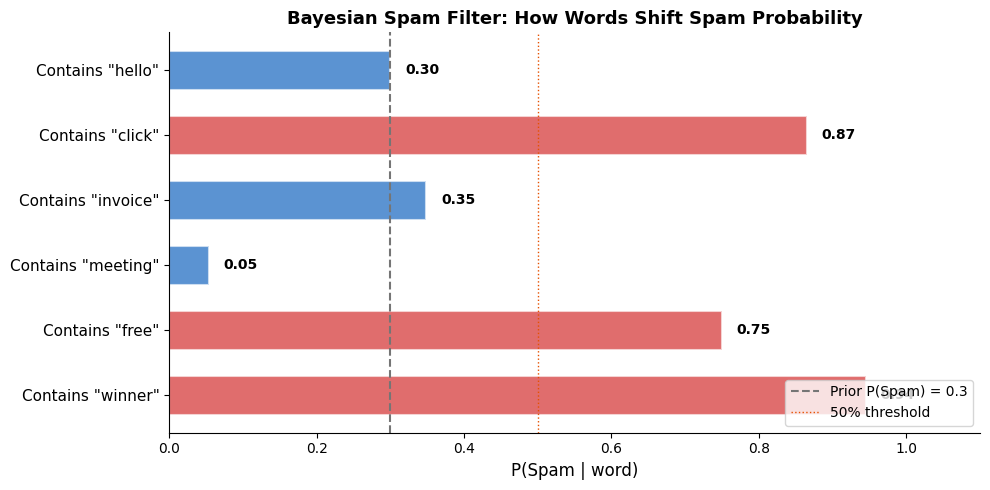

In [19]:
# --- Visual: how different words shift spam probability ---

words = {
    "winner":    (0.40, 0.01),
    "free":      (0.35, 0.05),
    "meeting":   (0.02, 0.15),
    "invoice":   (0.10, 0.08),
    "click":     (0.30, 0.02),
    "hello":     (0.10, 0.10),
}

fig, ax = plt.subplots(figsize=(10, 5))

word_names = list(words.keys())
posteriors_spam = []
for w, (p_w_spam, p_w_legit) in words.items():
    p_e = p_w_spam * P_spam + p_w_legit * (1 - P_spam)
    posteriors_spam.append((p_w_spam * P_spam) / p_e)

y = np.arange(len(word_names))
colors_bar = ["#D32F2F" if p > 0.5 else "#1565C0" for p in posteriors_spam]

bars = ax.barh(y, posteriors_spam, 0.6, color=colors_bar, alpha=0.7,
               edgecolor="white", linewidth=1.5)
ax.axvline(P_spam, color="#757575", linewidth=1.5, linestyle="--",
           label=f"Prior P(Spam) = {P_spam}")
ax.axvline(0.5, color="#E65100", linewidth=1, linestyle=":",
           label="50% threshold")

for i, v in enumerate(posteriors_spam):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels([f'Contains "{w}"' for w in word_names], fontsize=11)
ax.set_xlabel("P(Spam | word)", fontsize=12)
ax.set_title("Bayesian Spam Filter: How Words Shift Spam Probability",
             fontsize=13, fontweight="semibold")
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(0, 1.1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

- Words like **"winner"** and **"click"** that appear far more in spam than legitimate email push the posterior above 50%.
- **"meeting"** appears more in legitimate email, so it actually **decreases** spam probability below the prior.
- **"hello"** appears equally in both, so the posterior equals the prior — this word provides no information.

---

## 12. Common Pitfalls

### Pitfall 1: Base Rate Neglect

Ignoring the prior $P(B)$ is the most common error. A test with 99% accuracy can still give mostly false positives if the condition is rare.

In [20]:
# --- Base rate neglect demonstration ---

print("99% accurate test, but disease affects only 1 in 10,000 people:")
print()

P_disease = 0.0001  # 1 in 10,000
P_pos_disease = 0.99
P_pos_healthy = 0.01  # 1% false positive

posterior = bayes_medical(P_disease, P_pos_disease, P_pos_healthy)

print(f"P(Disease)         = {P_disease}  (1 in 10,000)")
print(f"P(+|Disease)       = {P_pos_disease}  (99% sensitivity)")
print(f"P(+|No Disease)    = {P_pos_healthy}  (1% false positive)")
print()
print(f"P(Disease | +)     = {posterior:.4f}  ({posterior:.2%})")
print()
print(f"Even with a 99% accurate test, a positive result means")
print(f"less than 1% chance of actually having the disease!")
print()
print("In 10,000 people:")
n_pop = 10000
tp = round(n_pop * P_disease * P_pos_disease)
fp = round(n_pop * (1 - P_disease) * P_pos_healthy)
print(f"  True positives:  ~{tp}")
print(f"  False positives: ~{fp}")
print(f"  Total positive:  ~{tp + fp}")
print(f"  P(Disease|+) = {tp}/{tp+fp} = {tp/(tp+fp):.4f}")

99% accurate test, but disease affects only 1 in 10,000 people:

P(Disease)         = 0.0001  (1 in 10,000)
P(+|Disease)       = 0.99  (99% sensitivity)
P(+|No Disease)    = 0.01  (1% false positive)

P(Disease | +)     = 0.0098  (0.98%)

Even with a 99% accurate test, a positive result means
less than 1% chance of actually having the disease!

In 10,000 people:
  True positives:  ~1
  False positives: ~100
  Total positive:  ~101
  P(Disease|+) = 1/101 = 0.0099


### Pitfall 2: Confusing P(E|B) with P(B|E)

Just as we saw with conditional probability, **the direction matters**:

- $P(+|\text{Disease})$ = test sensitivity (easy to measure)
- $P(\text{Disease}|+)$ = what the patient actually wants to know

These are generally very different numbers. Bayes' Theorem is the bridge.

---

## 13. Summary

| Concept | Formula |
|---|---|
| Bayes' Theorem (classic) | $P(B \mid E) = \frac{P(E \mid B) \cdot P(B)}{P(E)}$ |
| With Total Probability | $P(B \mid E) = \frac{P(E \mid B) \cdot P(B)}{P(E \mid B) \cdot P(B) + P(E \mid B^C) \cdot P(B^C)}$ |
| General ($n$ hypotheses) | $P(B_i \mid E) = \frac{P(E \mid B_i) \cdot P(B_i)}{\sum_j P(E \mid B_j) \cdot P(B_j)}$ |
| Odds form | $\frac{P(B \mid E)}{P(B^C \mid E)} = \frac{P(E \mid B)}{P(E \mid B^C)} \cdot \frac{P(B)}{P(B^C)}$ |

### Key Takeaways

1. Bayes' Theorem **reverses** conditional probabilities: from $P(E|B)$ to $P(B|E)$.
2. The **prior matters enormously** — rare events stay rare even with good tests (base rate neglect).
3. Posterior = Prior updated by evidence through the likelihood.
4. For multiple hypotheses, use the **law of total probability** in the denominator.
5. When $P(E)$ is unknown, use the **odds ratio** trick.
6. Bayes can be applied **sequentially** — today's posterior is tomorrow's prior.